<a href="https://colab.research.google.com/github/Rajeshpatra12/Rajeshpatra12/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Importing Dataset

In [10]:
# Step 2: Load Dataset (download CSV from Kaggle)
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Tweets.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (14640, 15)


In [11]:
print(df[['text','airline_sentiment']].head())

                                                text airline_sentiment
0                @VirginAmerica What @dhepburn said.           neutral
1  @VirginAmerica plus you've added commercials t...          positive
2  @VirginAmerica I didn't today... Must mean I n...           neutral
3  @VirginAmerica it's really aggressive to blast...          negative
4  @VirginAmerica and it's a really big bad thing...          negative


In [12]:
# Step 3: Keep only required columns
df = df[['text','airline_sentiment']]

In [13]:
# Step 4: Encode labels
sentiment_mapping = {"negative":0, "neutral":1, "positive":2}
df['label'] = df['airline_sentiment'].map(sentiment_mapping)

In [14]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

In [15]:
# Step 6: Text Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [16]:
# Step 7: Train Logistic Regression Model
model = LogisticRegression(max_iter=300)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=300)

In [17]:
# Step 8: Predictions
y_pred = model.predict(X_test_vec)

In [18]:
# Step 9: Evaluation
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=['Negative','Neutral','Positive']
))

✅ Accuracy: 0.7957650273224044

Classification Report:
               precision    recall  f1-score   support

    Negative       0.83      0.93      0.87      1889
     Neutral       0.65      0.49      0.56       580
    Positive       0.79      0.63      0.70       459

    accuracy                           0.80      2928
   macro avg       0.76      0.68      0.71      2928
weighted avg       0.79      0.80      0.79      2928



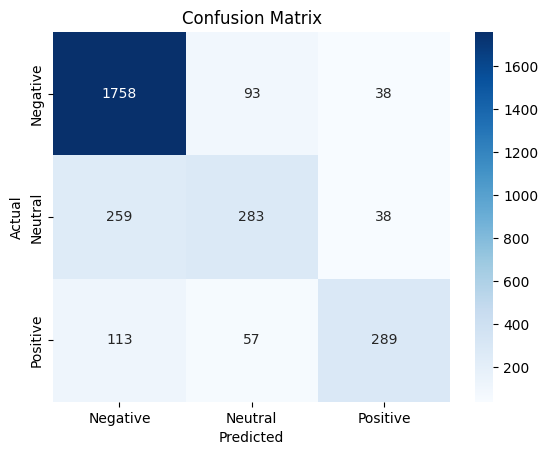

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
# Step 10: Test Custom Tweets
sample_tweets = [
    "I love the friendly service of this airline!",
    "The flight was delayed for 3 hours. Terrible experience.",
    "It was an okay flight, nothing special."
]
sample_vec = vectorizer.transform(sample_tweets)
preds = model.predict(sample_vec)

for tweet, pred in zip(sample_tweets, preds):
    sentiment = ["Negative","Neutral","Positive"][pred]
    print(f"Tweet: {tweet} --> Sentiment: {sentiment}")

Tweet: I love the friendly service of this airline! --> Sentiment: Positive
Tweet: The flight was delayed for 3 hours. Terrible experience. --> Sentiment: Negative
Tweet: It was an okay flight, nothing special. --> Sentiment: Negative
